In [92]:
import pandas as pd

In [93]:
df=pd.read_csv("/home/workstation-p/Downloads/Projects/datasets/Paysim/paysim.csv")

In [94]:
df.head(1)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0


In [95]:
df['type'].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [96]:
df['nameOrig'].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

In [97]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

In [98]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [99]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [100]:
fraud_df=df[df['isFraud']==1]
non_fraud_df=df[df["isFraud"]==0]

In [101]:
fraud_df.head(1)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0


In [102]:
non_fraud_df.head(1)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0


In [103]:
df_size=non_fraud_df.shape[0] if fraud_df.shape[0]>non_fraud_df.shape[0] else fraud_df.shape[0]

In [104]:
fraud_df.shape

(8213, 11)

In [105]:
non_fraud_df.shape

(6354407, 11)

In [106]:
df_balanced=pd.concat([non_fraud_df[:df_size],fraud_df[:df_size]])

In [107]:
df_balanced=df_balanced.sample(frac=1,random_state=42).reset_index(drop=True)

In [108]:
df_balanced['step']=df_balanced['step']%24

In [109]:
df_balanced.shape

(16426, 11)

In [110]:
df_balanced.head(1)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,16,TRANSFER,766151.45,C2014325113,766151.45,0.0,C432435900,0.0,0.0,1,0


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

In [112]:
X_train,X_test,y_train,y_test=train_test_split(df_balanced.drop(columns=["isFraud","nameOrig","nameDest","step","isFlaggedFraud"]),df_balanced["isFraud"],random_state=42,test_size=.75)

In [113]:
payment_encoder=LabelEncoder()
X_train["type"]=payment_encoder.fit_transform(X_train["type"])
X_test["type"]=payment_encoder.transform(X_test["type"])
scaler=StandardScaler()
for col in X_train.columns:
    X_train[col]=scaler.fit_transform(X_train[[col]])
    X_test[col]=scaler.transform(X_test[[col]])

In [114]:
from xgboost import XGBClassifier

In [115]:
xgboost=XGBClassifier()
xgboost.fit(X_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [ ]:
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,f1_score,precision_recall_curve
print(classification_report(y_test,xgboost.predict(X_test)))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6128
           1       0.99      0.99      0.99      6192

    accuracy                           0.99     12320
   macro avg       0.99      0.99      0.99     12320
weighted avg       0.99      0.99      0.99     12320



In [118]:
feature_importance=pd.DataFrame(
    {
        "feature":[ 'type', 'amount',  'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'],
        "Importance":xgboost.feature_importances_*100
    }
)
feature_importance

,feature,Importance
0,type,2.631391
1,amount,3.623293
2,oldbalanceOrg,11.616479
3,newbalanceOrig,81.459961
4,oldbalanceDest,0.354885
5,newbalanceDest,0.313993


In [119]:
from lightgbm import LGBMClassifier
lightbgm=LGBMClassifier()
lightbgm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 2021, number of negative: 2085
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000808 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1281
[LightGBM] [Info] Number of data points in the train set: 4106, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.492207 -> initscore=-0.031176
[LightGBM] [Info] Start training from score -0.031176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [120]:
print(classification_report(y_test,lightbgm.predict(X_test)))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      6128
           1       0.99      1.00      0.99      6192

    accuracy                           0.99     12320
   macro avg       0.99      0.99      0.99     12320
weighted avg       0.99      0.99      0.99     12320



In [121]:
feat_importance=pd.DataFrame({
    "Feature":[ 'type', 'amount',  'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest'],
    "Importance":lightbgm.feature_importances_
})
feat_importance

,Feature,Importance
0,type,249
1,amount,1087
2,oldbalanceOrg,872
3,newbalanceOrig,100
4,oldbalanceDest,421
5,newbalanceDest,270


In [122]:
import torch

In [123]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [124]:
X_train_tensor=torch.tensor(X_train.values,dtype=torch.float32,device=device).unsqueeze(1)
X_test_tensor=torch.tensor(X_test.values,dtype=torch.float32,device=device).unsqueeze(1)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.long,device=device)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.long,device=device)

In [125]:
from torch.utils.data import DataLoader,Dataset

In [126]:
class CustomDataset(Dataset):
    def __init__(self,features,labels):
        super().__init__()
        self.features=features
        self.labels=labels
    def __len__(self):
        return self.features.shape[0]
    def __getitem__(self, index):
        return self.features[index],self.labels[index]

In [127]:
train_dataset=CustomDataset(X_train_tensor,y_train_tensor)

In [128]:
train_dataloader=DataLoader(train_dataset,shuffle=True,batch_size=32)

In [129]:
class LSTM(torch.nn.Module):
    def __init__(self, input_layer,hidden_layer,output_layer ):
        super().__init__()
        self.network=torch.nn.LSTM(input_size=input_layer,hidden_size=hidden_layer,batch_first=True)
        self.fc=torch.nn.Linear(in_features=hidden_layer,out_features=output_layer)
        # self.sigmoid=torch.nn.Sigmoid()
    
    def forward(self,x):
        out,(hn,cn)=self.network(x)
        return self.fc(hn[-1])
        # return self.sigmoid(self.fc(hn[-1]))

In [130]:
lstm=LSTM(X_train.shape[1],64,y_train.unique().__len__())
lstm.to(device=device)
criterion=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=lstm.parameters(),lr=0.001)


In [131]:
epochs=1000
lstm.train()
for epoch in range(1,epochs+1):
    batch_size=32
    total_loss=0
    for batch_feature,batch_label in train_dataloader:
        output=lstm(batch_feature)
        loss=criterion(output,batch_label)
        optimizer.zero_grad()
        loss.backward()
        total_loss+=loss
        optimizer.step()
    if((epoch) %100)==0:
        print(f"epoch {epoch}, loss {total_loss/len(batch_feature)}")

epoch 100, loss 0.8122056126594543
epoch 200, loss 0.6932055354118347
epoch 300, loss 0.6085955500602722
epoch 400, loss 0.5902799963951111
epoch 500, loss 0.581472635269165
epoch 600, loss 0.5261777639389038
epoch 700, loss 0.5398117899894714
epoch 800, loss 0.5417556166648865
epoch 900, loss 0.5433791875839233
epoch 1000, loss 0.4834211766719818


In [132]:
lstm.eval()
test_dataset=CustomDataset(X_test_tensor,y_test_tensor)
test_loader=DataLoader(test_dataset,batch_size=32)
with torch.no_grad():
    lstm_logits=lstm(X_test_tensor)
    lstm_probs    = torch.softmax(lstm_logits, dim=1)
    lstm_class1   = lstm_probs[:, 1].detach().cpu().numpy()
    lstm_logits=lstm(X_train_tensor)
    lstm_probs    = torch.softmax(lstm_logits, dim=1)
    lstm_class2  = lstm_probs[:, 1].detach().cpu().numpy()

import numpy as np

meta_X_train = np.column_stack((
    xgboost.predict_proba(X_train)[:, 1],  # 1‑D array (n_samples,)
    lstm_class2                            # 1‑D array (n_samples,)
))

meta_X_test = np.column_stack((
    xgboost.predict_proba(X_test)[:, 1],   # 1‑D array (n_test,)
    lstm_class1                            # 1‑D array (n_test,)
))

final_probs=np.mean(meta_X_test,axis=1)
from sklearn.linear_model import LogisticRegression
meta_model = LogisticRegression()
meta_model.fit(meta_X_train, y_train)
meta_preds = meta_model.predict(meta_X_test)
print(classification_report(y_test, meta_preds))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      6128
           1       1.00      0.99      1.00      6192

    accuracy                           1.00     12320
   macro avg       1.00      1.00      1.00     12320
weighted avg       1.00      1.00      1.00     12320



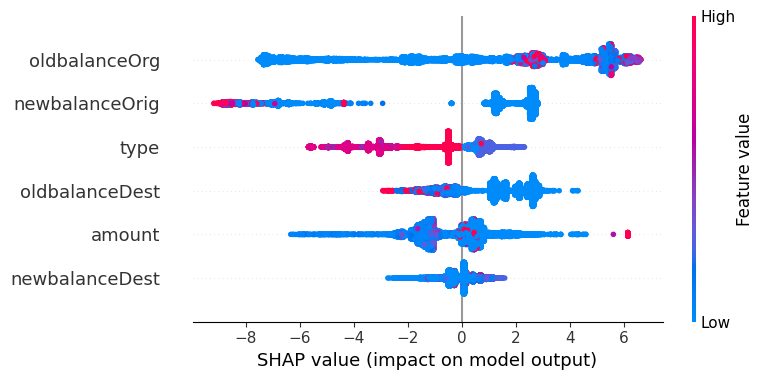

In [133]:
import shap
explainer = shap.TreeExplainer(xgboost)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)